# New York's revenue tree, Q2 against Q3

**Week 3, Wednesday. The trainer's parallel build, one notebook, run live in 60 minutes.** By the
end of it one metro's revenue change is explained from the raw files, every number reproduces
from the top, and the claim carries its denominators and its caveat.

Dr Priya Menon, COO of Kalpa Health, opened the week with her own words: *"Test volumes grew
5 percent against a plan of 18, and I do not know which branch of my business is short."* Her
data team added two things they know: two metros changed booking systems in Q3, and the posting
system keys claims in its own format. Your group holds one of her five sub-problems. This
notebook holds a smaller one, New York's billed revenue from Q2 (April to June) to Q3 (July to
September), solved in the open so the method is on the page and the finds stay with the groups.

> **Kavya's review.** Before anything leaves the team: show me the count you started from, every
> row you set aside and why, and a second way to reach the same total.

Monday mapped each sub-problem onto the Week 1 and 2 method. This notebook runs that method once,
end to end, on files nobody in the room has cleaned before.

The next cell finds the shared helper by walking up from this folder, then reads two of the
Kalpa Health files from Monday's data folder, `../../D1/data/`, with pandas. Every value is read
as text, so nothing is converted before it has been looked at.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import pandas as pd

DATA = pathlib.Path("../../D1/data")
raw_bookings = pd.read_csv(DATA / "C2_W03_D01_bookings_legacy_STUDENT.csv", dtype=str, keep_default_na=False)
raw_claims = pd.read_csv(DATA / "C2_W03_D01_claims_STUDENT.csv", dtype=str, keep_default_na=False)

# The slice: New York only. A group profiles its whole file; this build profiles the rows it uses.
bookings = raw_bookings[raw_bookings["metro"] == "New York"].copy()
claims = raw_claims[raw_claims["metro"] == "New York"].copy()

def quarter(dates):
    """Q2 is April to June and Q3 is July to September, calendar quarters, read from the ISO date text."""
    return dates.map(lambda d: "Q2" if d < "2026-07-01" else "Q3")

def usd(value, cents=False):
    """Dollars as a US price list prints them, with a thousands comma and, where asked, the cents."""
    v = float(value)
    text = f"${abs(v):,.2f}" if cents else f"${abs(round(v)):,}"
    return "-" + text if v < 0 else text

bookings["quarter"] = quarter(bookings["booking_date"])
claims["quarter"] = quarter(claims["service_date"])
STEPS = ["profile\nand the identity rule", "amounts\nevery one converts", "reconcile\nbookings to claims",
         "the tree\nQ2 against Q3", "the claim\nand its caveat"]
print(f"New York rows read: {len(bookings):,} from the old booking export, {len(claims):,} from the claims")

New York rows read: 2,128 from the old booking export, 2,032 from the claims


In [2]:
kit.side_by_side(
    kit.ladder(["Profile and the identity rule", "Amounts that convert", "Bookings reconciled to claims",
                "The tree, Q2 against Q3"], lit=None, show=False),
    kit.vflow(["one metro, two files\nthe old booking export and the claims",
               "one rule per decision\nwritten in the decisions log",
               "one claim\nwith its denominators and its caveat"], show=False),
)

## 1. Profile before touching: a row is not yet a booking

The claim at this level is that the file's row count and its booking count are two different
numbers until an identity rule makes them one. The old booking export holds 2,128 New York rows. A
hurried count calls that 2,128 bookings and moves on, and every rate built on it inherits the
error.

**Predict before you run.** How many New York bookings does the old export hold?
- a) exactly 2,128, one per row
- b) fewer than 2,128
- c) more than 2,128, since cancelled bookings sit elsewhere
- d) no way to tell until the claims file has been read

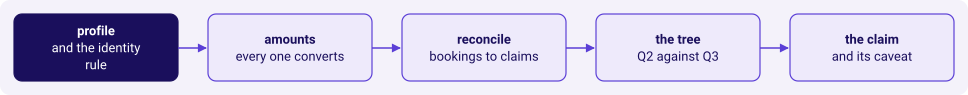

In [3]:
kit.flow(STEPS, lit=0)

In [4]:
def profile(df, columns):
    """Per column: filled, blank, distinct values, and one example, which is the Week 1 profile."""
    rows = []
    for c in columns:
        filled = (df[c] != "").sum()
        rows.append([c, f"{filled:,}", f"{len(df) - filled:,}", f"{df[c].nunique():,}", df[c].iloc[0]])
    return rows

kit.table(["Column", "Filled", "Blank", "Distinct", "Example"],
          profile(bookings, ["booking_id", "patient_id", "site_code", "booking_date", "channel", "status", "updated_at"]),
          caption=f"The old booking export, New York rows: {len(bookings):,}")
kit.table(["Column", "Filled", "Blank", "Distinct", "Example"],
          profile(claims, ["claim_id", "booking_id", "service_date", "billed_amount"]),
          caption=f"The claims, New York rows: {len(claims):,}. The tree reads these four columns.")

Column,Filled,Blank,Distinct,Example
booking_id,"2,128",0,"2,095",KB0002971
patient_id,"2,128",0,952,P-003269
site_code,"2,128",0,3,KH-NYC-02
booking_date,"2,128",0,183,2026-05-18
channel,"2,085",43,5,walk-in
status,"2,128",0,2,completed
updated_at,"2,128",0,"2,080",2026-05-18 19:17


Column,Filled,Blank,Distinct,Example
claim_id,"2,032",0,"2,032",KH-CLM-000033
booking_id,"2,032",0,"2,032",KB0000033
service_date,"2,032",0,183,2026-04-01
billed_amount,"2,032",0,85,180


**What happened.** The answer is b. The export holds 2,128 New York rows and 2,095 distinct
`booking_id` values, so 33 ids appear on two rows. The claims file is clean on the same test:
2,032 rows and 2,032 distinct claim ids. `channel` is blank on 43 rows; this tree splits by
site, so that column is logged as not used rather than cleaned. The billed amounts profile as
text, which the next level deals with.

In [5]:
distinct_ids = bookings["booking_id"].nunique()
kit.check("the export holds more rows than distinct booking ids", len(bookings) > distinct_ids,
          f"{len(bookings):,} rows, {distinct_ids:,} distinct ids")
kit.check("every claim id appears once", claims["claim_id"].is_unique, f"{len(claims):,} claims")
kit.check("every New York row carries a date and a status",
          (bookings["booking_date"] != "").all() and (bookings["status"] != "").all())

**The plausible wrong answer.** Count rows per quarter and call them bookings. New York then grows
from 1,039 to 1,089, a rise of 4.8 percent, and that is the number a hurried analyst would send.

Count,Q2,Q3,Change
Rows in the export (the wrong answer),"1,039","1,089",+4.8%
Distinct booking ids,"1,013","1,082",+6.8%


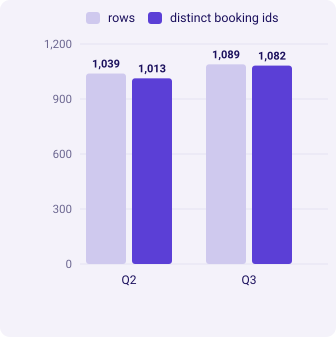

In [6]:
rows_q = bookings.groupby("quarter").size()
ids_q = bookings.groupby("quarter")["booking_id"].nunique()
wrong, right = rows_q["Q3"] / rows_q["Q2"] - 1, ids_q["Q3"] / ids_q["Q2"] - 1
kit.table(["Count", "Q2", "Q3", "Change"],
          [["Rows in the export (the wrong answer)", f"{rows_q['Q2']:,}", f"{rows_q['Q3']:,}", f"{wrong:+.1%}"],
           ["Distinct booking ids", f"{ids_q['Q2']:,}", f"{ids_q['Q3']:,}", f"{right:+.1%}"]],
          caption="New York, the old booking export")
kit.columns(["Q2", "Q3"], [("rows", [rows_q["Q2"], rows_q["Q3"]]),
                           ("distinct booking ids", [ids_q["Q2"], ids_q["Q3"]])])

**Why it is wrong.** The repeated ids are not spread evenly: 26 of the 33 extra rows sit in Q2
and 7 in Q3, so counting rows inflates the base quarter and makes New York look slower than it was.
A branch reported at 4.8 percent when it grew 6.8 percent could be the branch Dr Menon decides to
fix. The check that catches it is the one above: rows against distinct ids, per quarter.

**The identity rule.** One `booking_id` is one booking. Where two rows share an id, keep the row
with the later `updated_at`, since that is the system's latest word on the booking. Of the 33
pairs, 26 are identical in every field and 7 differ only in `updated_at`, so the rule decides
nothing it should not. Why a booking was exported twice is a question for Dr Menon's data team,
and it goes into the challenges log as a question; the rule does not depend on the answer.

In [7]:
pairs = bookings[bookings["booking_id"].duplicated(keep=False)].groupby("booking_id")
identical = sum(1 for _, g in pairs if len(g.drop_duplicates(subset=[c for c in g.columns if c != "quarter"])) == 1)
differs_only_in_updated = sum(1 for _, g in pairs
                              if len(g.drop_duplicates(subset=[c for c in g.columns if c != "quarter"])) == 2
                              and len(g.drop(columns=["updated_at"]).drop_duplicates()) == 1)

clean = (bookings.sort_values(["booking_id", "updated_at"])
                 .drop_duplicates("booking_id", keep="last"))
rejected = len(bookings) - len(clean)
kit.table(["Repeated ids", "Identical in every field", "Differ only in updated_at", "Rows set aside"],
          [[f"{pairs.ngroups}", f"{identical}", f"{differs_only_in_updated}", f"{rejected}"]],
          caption="What the identity rule decided")

Repeated ids,Identical in every field,Differ only in updated_at,Rows set aside
33,26,7,33


In [8]:
kit.check("input equals kept plus set aside", len(bookings) == len(clean) + rejected,
          f"{len(bookings):,} = {len(clean):,} + {rejected}")
kit.check("every repeated pair differs, if at all, only in updated_at",
          identical + differs_only_in_updated == pairs.ngroups, f"{identical} + {differs_only_in_updated}")
kit.check("the kept rows have one row per booking id", clean["booking_id"].is_unique)

## 2. Amounts: every dollar converts, or the total is short

The claim at this level is that revenue can only be summed once every amount is a number, and a
conversion that fails quietly is worse than one that fails loudly. The `billed_amount` column was read
as text. The quick fix is `pd.to_numeric(..., errors="coerce")`, which turns anything it cannot
read into a blank and lets the sum carry on.

**Predict before you run.** What does the coerced sum do on New York's claims?
- a) it stops with an error on the first amount it cannot read
- b) it matches the true total to the dollar, since coerce only changes the type
- c) it comes out short, because a few amounts become blanks
- d) it doubles, since a text amount is concatenated before the sum adds it

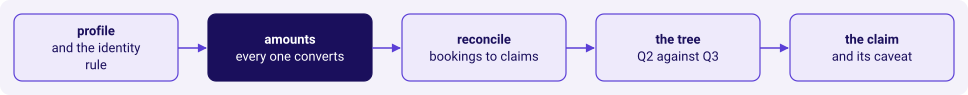

In [9]:
kit.flow(STEPS, lit=1)

In [10]:
coerced = pd.to_numeric(claims["billed_amount"], errors="coerce")
dropped = claims[coerced.isna()]
wrong_total = coerced.groupby(claims["quarter"]).sum()
kit.table(["What the coerced sum shows", "Q2", "Q3"],
          [["Billed revenue", usd(wrong_total["Q2"]), usd(wrong_total["Q3"])],
           ["Amounts turned into blanks", f"{(dropped['quarter'] == 'Q2').sum()}", f"{(dropped['quarter'] == 'Q3').sum()}"]],
          caption="The plausible wrong answer")
print("The amounts it could not read:", ", ".join(dropped["billed_amount"]))

What the coerced sum shows,Q2,Q3
Billed revenue,"$174,242","$184,250"
Amounts turned into blanks,5,1


The amounts it could not read: $170.00, $149.00, $60.00, $140.00, $149.00, $235.00


**What happened.** The answer is c. Six amounts are written as text with a dollar sign and
cents, as a spreadsheet prints currency, and coerce turned each into a blank. The Q2 total comes
out $668 short and Q3 $235 short. **Why it is wrong.** Nothing on the screen says anything
was lost, so the finance head's books and this notebook would disagree by $903 with no row to
point at. The check that catches it counts the amounts that failed to convert, which must be zero
before any total is read. The fix removes the dollar sign and any comma and converts strictly, so
any amount still unreadable stops the run.

In [11]:
claims["amount_usd"] = (claims["billed_amount"].str.replace("$", "", regex=False)
                        .str.replace(",", "", regex=False).astype(float))
right_total = claims.groupby("quarter")["amount_usd"].sum()
kit.table(["Billed revenue", "Q2", "Q3"],
          [["Coerced (wrong)", usd(wrong_total["Q2"]), usd(wrong_total["Q3"])],
           ["Every amount converted", usd(right_total["Q2"]), usd(right_total["Q3"])],
           ["What the blanks hid", usd(right_total["Q2"] - wrong_total["Q2"]),
            usd(right_total["Q3"] - wrong_total["Q3"])]],
          caption="New York claims, the same rows summed two ways")

Billed revenue,Q2,Q3
Coerced (wrong),"$174,242","$184,250"
Every amount converted,"$174,910","$184,485"
What the blanks hid,$668,$235


In [12]:
kit.check("no amount is left unconverted", claims["amount_usd"].notna().all(), f"{len(claims):,} amounts")
kit.check("the fix recovers exactly what coerce dropped",
          round(right_total.sum() - wrong_total.sum(), 2) == round(claims.loc[dropped.index, "amount_usd"].sum(), 2),
          usd(right_total.sum() - wrong_total.sum()))

## 3. Reconcile: every completed booking has one claim, and nothing else has one

The claim at this level is that the claims file and the booking export describe the same
bookings, and a join proves it only when it is checked in both directions and on its grain. A
hurried join puts the raw export beside the claims on `booking_id` and sums the amounts.

**Predict before you run.** Joining the raw New York export to the New York claims on `booking_id`
gives how many rows?
- a) 2,032, one per claim
- b) 2,128, one per export row
- c) more than 2,032 but fewer than 2,128
- d) fewer than 2,032, since cancelled rows fall away

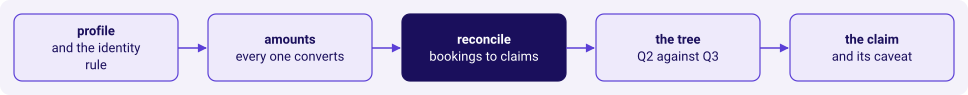

In [13]:
kit.flow(STEPS, lit=2)

In [14]:
fanned = bookings.merge(claims, on="booking_id", suffixes=("", "_clm"))
kit.table(["Joined on the raw export", "Rows", "Billed revenue"],
          [["The plausible wrong answer", f"{len(fanned):,}", usd(fanned["amount_usd"].sum())],
           ["The claims themselves", f"{len(claims):,}", usd(claims["amount_usd"].sum())]],
          caption="The same claims, joined before and without the identity rule")

Joined on the raw export,Rows,Billed revenue
The plausible wrong answer,"2,065","$364,853"
The claims themselves,"2,032","$359,395"


**What happened.** The answer is c: 2,065 rows. Each repeated booking that was completed carries
its claim twice, so the joined billed revenue reads $364,853 against $359,395 in the claims
file, $5,458 too much, with most of it landing in Q2. **Why it is wrong.** The join changed
the grain from one row per claim to one row per export row without saying so, which is the
Week 2 fan-out. The check that catches it is `validate="one_to_one"`, which refuses the join the
moment either side repeats a key.

In [15]:
with kit.expect_error() as err:
    bookings.merge(claims, on="booking_id", validate="one_to_one")
kit.check("the unchecked join is refused on its grain", err.name == "MergeError", err.message)

The fix joins the kept rows, with the grain declared, and keeps both sides visible with an
outer join, so a booking with no claim and a claim with no booking would each show up
rather than vanish. Then the reconciliation is written down as arithmetic: rows read, rows set
aside, bookings kept, bookings cancelled, bookings completed, claims matched.

Step,Rows
Rows read from the old export,"2,128"
Set aside by the identity rule,33
Bookings kept,"2,095"
"of which cancelled, no claim expected",63
of which completed,"2,032"
Completed bookings matched to one claim,"2,032"
Claims with no booking in the export,0
Bookings with a claim though cancelled,0


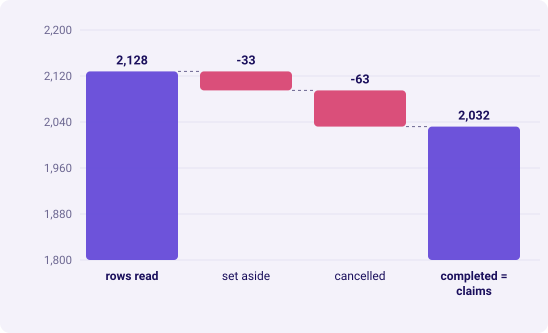

In [16]:
joined = clean.merge(claims, on="booking_id", how="outer", validate="one_to_one",
                     suffixes=("", "_clm"), indicator=True)
side = joined["_merge"].value_counts()
completed = clean[clean["status"] == "completed"]
cancelled = clean[clean["status"] == "cancelled"]
matched = joined[joined["_merge"] == "both"]
kit.table(["Step", "Rows"],
          [["Rows read from the old export", f"{len(bookings):,}"],
           ["Set aside by the identity rule", f"{rejected}"],
           ["Bookings kept", f"{len(clean):,}"],
           ["of which cancelled, no claim expected", f"{len(cancelled)}"],
           ["of which completed", f"{len(completed):,}"],
           ["Completed bookings matched to one claim", f"{(matched['status'] == 'completed').sum():,}"],
           ["Claims with no booking in the export", f"{side.get('right_only', 0)}"],
           ["Bookings with a claim though cancelled", f"{(matched['status'] == 'cancelled').sum()}"]],
          caption="New York, Q2 and Q3 together")
kit.bridge(("rows read", len(bookings)),
           [("set aside", -rejected), ("cancelled", -len(cancelled))],
           end_label="completed = claims", fmt=lambda v: f"{v:,.0f}", lo=1800)

In [17]:
kit.check("rows read equal kept plus set aside", len(bookings) == len(clean) + rejected)
kit.check("every completed booking has exactly one claim",
          (matched["status"] == "completed").sum() == len(completed) == len(claims),
          f"{len(completed):,} completed, {len(claims):,} claims")
kit.check("no claim lacks a booking, and no cancelled booking is billed",
          side.get("right_only", 0) == 0 and (matched["status"] == "cancelled").sum() == 0)

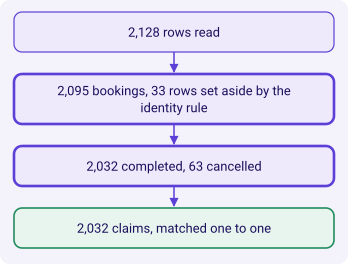

What the build can now say,The evidence
"New York's old export holds 2,095 bookings in 2,128 rows","33 repeated ids, 26 identical, 7 differing only in updated_at"
Every New York amount is a number,"6 amounts written as dollar text converted, none left blank"
"Claims and completed bookings are the same 2,032","outer join, one to one, nothing on either side unmatched"


In [18]:
kit.vflow(["2,128 rows read", "2,095 bookings, 33 rows set aside by the identity rule",
           "2,032 completed, 63 cancelled", "2,032 claims, matched one to one"],
          kinds=["plain", "known", "known", "good"])
kit.table(["What the build can now say", "The evidence"],
          [["New York's old export holds 2,095 bookings in 2,128 rows", "33 repeated ids, 26 identical, 7 differing only in updated_at"],
           ["Every New York amount is a number", "6 amounts written as dollar text converted, none left blank"],
           ["Claims and completed bookings are the same 2,032", "outer join, one to one, nothing on either side unmatched"]],
          caption="What the first three levels established")

## 4. The tree: more claims at a lower mean moved New York's revenue

The claim at this level is that New York's billed revenue change splits into how many claims were
billed and what each was worth on average, and that each leaf is read against its own denominator.
Billed revenue is claims multiplied by the mean claim; claims are completed bookings. This is the
Week 1 tree, with a booking in place of an order and a claim in place of a bill.

**Predict before you run.** New York's billed revenue rose from Q2 to Q3. Which leaf moved it?
- a) more claims, each worth less on average
- b) fewer claims, each worth more on average
- c) more claims, each worth more on average
- d) the same number of claims, each worth more on average

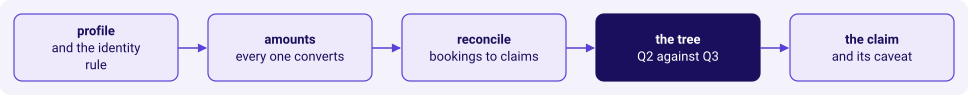

In [19]:
kit.flow(STEPS, lit=3)

Leaf,Q2,Q3,Change
Billed revenue,"$174,910","$184,485",+5.5%
Claims (completed bookings),977,"1,055",+8.0%
Mean claim,$179.03,$174.87,-2.3%
Median claim,$150,$150,+0.0%


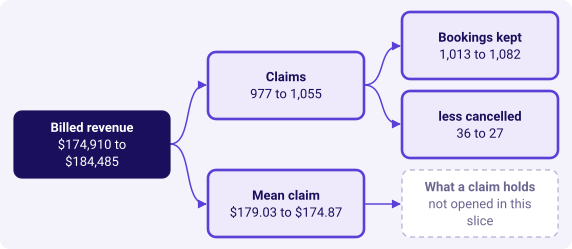

In [20]:
tree = claims.groupby("quarter")["amount_usd"].agg(["count", "sum", "mean", "median"])
q2, q3 = tree.loc["Q2"], tree.loc["Q3"]
kept_q = clean.groupby("quarter").size()
cancel_q = clean[clean["status"] == "cancelled"].groupby("quarter").size()
def move(a, b):
    return f"{b / a - 1:+.1%}"
kit.table(["Leaf", "Q2", "Q3", "Change"],
          [["Billed revenue", usd(q2["sum"]), usd(q3["sum"]), move(q2["sum"], q3["sum"])],
           ["Claims (completed bookings)", f"{int(q2['count']):,}", f"{int(q3['count']):,}", move(q2["count"], q3["count"])],
           ["Mean claim", usd(q2["mean"], cents=True), usd(q3["mean"], cents=True), move(q2["mean"], q3["mean"])],
           ["Median claim", usd(q2["median"]), usd(q3["median"]), move(q2["median"], q3["median"])]],
          caption="New York, from the claims, after levels 1 to 3")
kit.driver_tree({"label": "Billed revenue", "note": f"{usd(q2['sum'])} to {usd(q3['sum'])}", "kind": "lit",
                 "children": [
                     {"label": "Claims", "note": f"{int(q2['count']):,} to {int(q3['count']):,}", "kind": "known",
                      "children": [{"label": "Bookings kept", "note": f"{kept_q['Q2']:,} to {kept_q['Q3']:,}", "kind": "known"},
                                   {"label": "less cancelled", "note": f"{cancel_q['Q2']} to {cancel_q['Q3']}", "kind": "known"}]},
                     {"label": "Mean claim", "note": f"{usd(q2['mean'], cents=True)} to {usd(q3['mean'], cents=True)}",
                      "kind": "known",
                      "children": [{"label": "What a claim holds", "note": "not opened in this slice", "kind": "unknown"}]}]})

**What happened.** The answer is a. Claims rose 8.0 percent and the mean claim fell 2.3
percent, so billed revenue rose 5.5 percent, from $174,910 to $184,485. A bridge splits the
$9,575 into its two leaves: the extra 78 claims at Q2's mean add $13,964, and Q3's lower
mean across all 1,055 claims takes away $4,389.

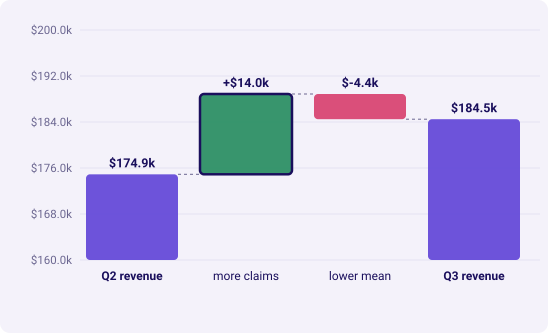

In [21]:
volume = (q3["count"] - q2["count"]) * q2["mean"]
value = q3["count"] * (q3["mean"] - q2["mean"])
kit.bridge(("Q2 revenue", q2["sum"]), [("more claims", round(volume)), ("lower mean", round(value))],
           end_label="Q3 revenue", lit=[0], lo=160000, fmt=lambda v: f"${v / 1000:,.1f}k")
kit.check("the two leaves add up to the change in revenue", round(volume + value) == round(q3["sum"] - q2["sum"]),
          f"{usd(volume)} and {usd(value)}")
kit.check("more claims and a lower mean, as predicted", q3["count"] > q2["count"] and q3["mean"] < q2["mean"])

**The plausible wrong answer.** "New York billed 8.0 percent more claims in Q3." It is true of the
totals and wrong as a rate. **Why it is wrong.** Q2 runs 91 days and Q3 runs 92, so one extra
day of trading is inside the 8.0 percent. Per day, claims rose 6.8 percent and billed revenue 4.3
percent. A comparison against a plan set per month or per day needs the per-day figure, and a
claim that quotes totals has to say the windows differ. The check compares the two windows'
lengths before any rate is written.

In [22]:
days = {"Q2": 91, "Q3": 92}
kit.check("the two quarters are different lengths", days["Q2"] != days["Q3"], "91 and 92 days")
per_day = {q: (tree.loc[q, "count"] / days[q], tree.loc[q, "sum"] / days[q]) for q in days}
kit.table(["Per day", "Q2", "Q3", "Change"],
          [["Claims", f"{per_day['Q2'][0]:.2f}", f"{per_day['Q3'][0]:.2f}", move(per_day["Q2"][0], per_day["Q3"][0])],
           ["Billed revenue", usd(per_day["Q2"][1]), usd(per_day["Q3"][1]), move(per_day["Q2"][1], per_day["Q3"][1])]],
          caption="New York, the same totals over 91 and 92 days")

Per day,Q2,Q3,Change
Claims,10.74,11.47,+6.8%
Billed revenue,"$1,922","$2,005",+4.3%


The last split this slice makes is by site, because `site_code` sits on the booking and
every New York booking carries one. It says where inside New York the extra claims were billed. The
split stops there. Below the mean claim sits what each claim holds, and why the mean fell is
a question the claims file cannot answer on its own; it goes into the challenges log as a
question for the branch below, which this slice does not open.

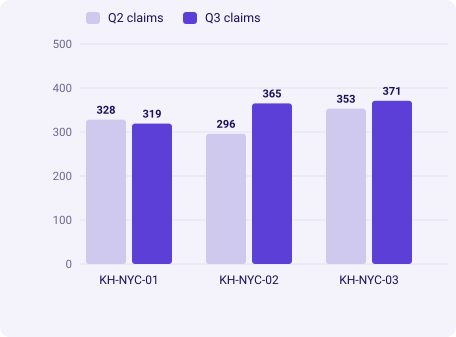

Site,Q2 claims,Q3 claims,Q2 billed,Q3 billed
KH-NYC-01,328,319,"$57,526","$55,765"
KH-NYC-02,296,365,"$52,840","$65,271"
KH-NYC-03,353,371,"$64,544","$63,449"


In [23]:
by_site = clean.merge(claims, on="booking_id", validate="one_to_one", suffixes=("", "_clm")).groupby(["site_code", "quarter"])["amount_usd"].agg(["count", "sum"])
sites = sorted(clean["site_code"].unique())
kit.columns(sites, [("Q2 claims", [by_site.loc[(c, "Q2"), "count"] for c in sites]),
                    ("Q3 claims", [by_site.loc[(c, "Q3"), "count"] for c in sites])])
kit.table(["Site", "Q2 claims", "Q3 claims", "Q2 billed", "Q3 billed"],
          [[c, f"{by_site.loc[(c, 'Q2'), 'count']:,}", f"{by_site.loc[(c, 'Q3'), 'count']:,}",
            usd(by_site.loc[(c, "Q2"), "sum"]), usd(by_site.loc[(c, "Q3"), "sum"])] for c in sites],
          caption="New York by site, from the kept bookings joined to their claims")
kit.check("the site leaves add back to the metro total", round(by_site["sum"].sum(), 2) == round(claims["amount_usd"].sum(), 2),
          usd(by_site["sum"].sum()))

## The claim, the decisions log and where this build stops

The claim is written in the Week 1 Thursday shape, claim first, so it survives being read for
two minutes and put down.

| Part | New York, Q2 against Q3 |
|---|---|
| **Claim** | New York's billed revenue rose 5.5 percent, from $174,910 on 977 claims in Q2 to $184,485 on 1,055 in Q3, because it billed more claims at a slightly lower mean. |
| **Evidence** | 2,128 rows of the old export reduced to 2,095 bookings by one identity rule; the 2,032 completed ones matched one to one to 2,032 claims; billed revenue split into 78 more claims (plus $13,964) and a mean $4.16 lower (minus $4,389). |
| **Caveat** | This is billed revenue, which is not the same as money collected, and Q3 is one day longer than Q2: per day, billed revenue rose 4.3 percent. Why the mean claim fell is not yet known. |
| **Action** | Treat New York as growing modestly on volume, and open the branch below the claim before deciding whether the lower mean is a price, a mix or a fee question. |

The decisions log follows the Week 1 Wednesday shape, one row per decision, and it includes a row
that was kept.

Field,Issue,Rows,Decision,Reason
booking_id,33 ids appear on two rows,33,Keep the row with the later updated_at,"One id is one booking; 26 pairs are identical and 7 differ only in updated_at, so no booking fact is lost"
billed_amount,6 amounts written as text with a dollar sign,6,"Remove the dollar sign and any comma, convert strictly",Coerce would blank them and leave billed revenue $903 short with no error
channel,Blank on 43 rows,43,Kept as they are,"This tree splits by site, so the blanks change no number here; logged for any channel split"
status,63 cancelled bookings carry no claim,63,"Kept, outside billed revenue",A cancelled booking is a real booking that earns nothing; the reconciliation shows each one


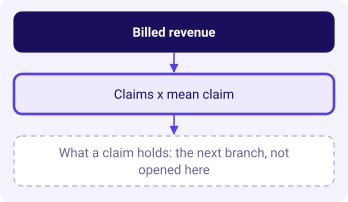

In [24]:
kit.table(["Field", "Issue", "Rows", "Decision", "Reason"],
          [["booking_id", "33 ids appear on two rows", "33", "Keep the row with the later updated_at",
            "One id is one booking; 26 pairs are identical and 7 differ only in updated_at, so no booking fact is lost"],
           ["billed_amount", "6 amounts written as text with a dollar sign", "6", "Remove the dollar sign and any comma, convert strictly",
            "Coerce would blank them and leave billed revenue $903 short with no error"],
           ["channel", "Blank on 43 rows", "43", "Kept as they are",
            "This tree splits by site, so the blanks change no number here; logged for any channel split"],
           ["status", "63 cancelled bookings carry no claim", "63", "Kept, outside billed revenue",
            "A cancelled booking is a real booking that earns nothing; the reconciliation shows each one"]],
          caption="The decisions log for the New York slice")
kit.vflow(["Billed revenue", "Claims x mean claim", "What a claim holds: the next branch, not opened here"],
          kinds=["lit", "known", "unknown"])

### In the interview

**[F] Two systems export the same entity with different id formats; how do you reconcile them?**
Write one rule that turns each format into a single canonical key, and apply it to both sides
rather than editing either export. Prove the rule on the rows: report how many matched before
and after, then anti-join in both directions and classify every leftover, because an unmatched
row is either a real gap or a defect in the rule. Check the grain on the way, so a key repeated on
one side is caught before it doubles a total, and write the rule in the decisions log so the
finance head can rerun it.

**[D] State your finding in one sentence a COO can carry into a board meeting.** The claim above
is the model: the number, its two denominators, the period, and the reason, in one sentence,
with the caveat one line below it and never folded into it.

> **Kavya's review.** The count you started from is on the page, every row set aside has a
> reason, and the sites add back to the metro. The second way to the same total is the bridge.

In [25]:
kit.check_summary()
print("Next: your group's own cut, run the same way, with its claim ready for the close.")

Next: your group's own cut, run the same way, with its claim ready for the close.
